### 🔥 Deep Learning Cave — Chapter 5: The World Model Sanctum

> *"Predict what matters, ignore the noise — this is how intelligence learns."*

You've reached a deeper chamber. Here lies **I-JEPA** — Yann LeCun's vision for the future of AI. Not reconstruction, not contrastive learning, but **prediction in abstract space**.

**Chapter 5** builds a self-supervised system that learns rich representations without labels, without pixel reconstruction — just pure semantic prediction.

---

#### 🗺️ Your Position in the Cave

```
[■■■■■■■■■■] Chapter 1: PyTorch Foundations ✓
[■■■■■■■■■■] Chapter 2: The Original Transformer ✓
[■■■■■■■■■■] Chapter 3: Modern LLaMA ✓
[■■■■■■■■■■] Chapter 4: Vision Transformer ✓
[■■□□□□□□□□] Chapter 5: I-JEPA ← You are here
 ├── Multi-block semantic masking
 ├── EMA target encoder
 └── Latent space prediction

[□□□□□□□□□□] Chapter 6: Coming soon...
```

**Paper**: *"Self-Supervised Learning from Images with a Joint-Embedding Predictive Architecture"* (Assran et al., 2023)

---

#### What We're Building

**I-JEPA** (Image-based Joint-Embedding Predictive Architecture) is Yann LeCun's vision for the next generation of self-supervised learning. The core insight:

> **Predict in latent (representation) space, not pixel space.**

Unlike MAE (Masked Autoencoders) which reconstructs pixels, JEPA predicts **abstract representations** of masked regions — forcing the model to learn high-level semantics.

```
┌─────────────────────────────────────────────────────────────────┐
│                     I-JEPA Architecture                         │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│    Image                                                        │
│      │                                                          │
│      ├────────────────┬──────────────────┐                      │
│      │                │                  │                      │
│      ▼                ▼                  ▼                      │
│  ┌────────┐      ┌────────┐        ┌──────────┐                │
│  │ Context│      │ Target │        │ Predictor│                │
│  │Encoder │      │Encoder │        │ (narrow  │                │
│  │ (ViT)  │      │ (EMA)  │        │   ViT)   │                │
│  └───┬────┘      └───┬────┘        └────┬─────┘                │
│      │               │                  │                      │
│      │   visible     │   full           │  predicts            │
│      │   patches     │   image          │  target              │
│      │               │                  │  embeddings          │
│      │               │                  │                      │
│      │               ▼                  ▼                      │
│      │          ┌─────────┐       ┌─────────┐                  │
│      │          │  Target │       │Predicted│                  │
│      └─────────►│  Repr.  │◄─────►│  Repr.  │                  │
│                 └─────────┘       └─────────┘                  │
│                      │                 │                       │
│                      └────────┬────────┘                       │
│                               │                                │
│                               ▼                                │
│                        L1 Loss in                              │
│                        Latent Space                            │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

#### Why JEPA Matters

| Approach | What it predicts | Problem |
|----------|-----------------|---------|
| **MAE** | Pixels | Wastes capacity on low-level details |
| **Contrastive** (SimCLR, CLIP) | Similarity scores | Needs negative samples, hand-crafted augmentations |
| **JEPA** | Abstract representations | No pixel reconstruction, no negatives! |

---

#### Learning Path

| Part | Component | What You'll Learn |
|------|-----------|------------------|
| 1 | Setup & Config | JEPA hyperparameters |
| 2 | ViT Encoder | Backbone (from previous notebook) |
| 3 | Predictor Network | Narrow ViT that predicts target representations |
| 4 | Multi-Block Masking | JEPA's key innovation: semantic block masking |
| 5 | EMA Target Encoder | Exponential moving average for stable targets |
| 6 | Loss Function | Smooth L1 loss in latent space |
| 7 | Data Pipeline | ImageNet-style preparation |
| 8 | Training Loop | Self-supervised training |
| 9 | Evaluation | Linear probing and feature quality |

**Prerequisites**: `vit_from_scratch.ipynb` (Vision Transformer)

---

### Part 1: Setup and Configuration

🎯 **What it does**: Define I-JEPA architecture hyperparameters

🔧 **Why it matters**: JEPA has three networks (context encoder, target encoder, predictor) with different sizes. The predictor is intentionally narrower than the encoders.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # Fix OpenMP conflict on macOS

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import copy
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.manifold import TSNE

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


In [2]:
@dataclass
class JEPAConfig:
    # Image parameters
    img_size: int = 224          # Standard ImageNet size (or 32 for CIFAR)
    patch_size: int = 16         # 16x16 patches
    in_channels: int = 3
    
    # Encoder parameters (ViT-Base-like)
    d_model: int = 384           # Embedding dimension
    n_heads: int = 6             # Attention heads
    n_layers: int = 6            # Transformer blocks
    d_ff: int = 1536             # FFN hidden dimension (4x d_model)
    dropout: float = 0.0         # No dropout in self-supervised pretraining
    
    # Predictor parameters (narrower than encoder)
    pred_d_model: int = 192      # Predictor is narrower (half of encoder)
    pred_n_heads: int = 6
    pred_n_layers: int = 6       # Same depth as encoder
    
    # Masking parameters (JEPA-specific)
    context_mask_scale: tuple = (0.85, 1.0)   # Context sees 85-100% of image
    target_mask_scale: tuple = (0.15, 0.2)    # Target blocks are 15-20% of image
    target_aspect_ratio: tuple = (0.75, 1.5)  # Aspect ratio of target blocks
    n_targets: int = 4                         # Number of target blocks to predict
    
    # EMA parameters
    ema_momentum: float = 0.996  # Momentum for target encoder EMA (increases during training)
    
    # Derived
    n_patches: int = None
    grid_size: int = None
    
    def __post_init__(self):
        self.grid_size = self.img_size // self.patch_size
        self.n_patches = self.grid_size ** 2

# Use smaller config for educational demo (CIFAR-10 compatible)
config = JEPAConfig(
    img_size=32,       # CIFAR-10 size
    patch_size=4,      # 4x4 patches → 64 patches
    d_model=256,
    n_heads=4,
    n_layers=4,
    d_ff=512,
    pred_d_model=128,
    pred_n_heads=4,
    pred_n_layers=4,
)

print(f"Image: {config.img_size}x{config.img_size}")
print(f"Patch size: {config.patch_size}x{config.patch_size}")
print(f"Grid size: {config.grid_size}x{config.grid_size}")
print(f"Number of patches: {config.n_patches}")
print(f"\nEncoder dimension: {config.d_model}")
print(f"Predictor dimension: {config.pred_d_model}")
print(f"\nTarget blocks per image: {config.n_targets}")

Image: 32x32
Patch size: 4x4
Grid size: 8x8
Number of patches: 64

Encoder dimension: 256
Predictor dimension: 128

Target blocks per image: 4


💡 **Key Insight**: The predictor is intentionally **narrower** than the encoder (192 vs 384 dimensions). This prevents the model from simply copying features — it must compress and predict, learning meaningful abstractions.

---

### Part 2: ViT Encoder Backbone

🎯 **What it does**: The encoder converts image patches into representations

🔧 **Why it matters**: We reuse our ViT architecture from the previous notebook, with one modification: no CLS token (JEPA operates on patch representations directly).

In [3]:
class PatchEmbedding(nn.Module):
    """Convert image to sequence of patch embeddings."""
    
    def __init__(self, config, d_model=None):
        super().__init__()
        d_model = d_model or config.d_model
        self.projection = nn.Conv2d(
            in_channels=config.in_channels,
            out_channels=d_model,
            kernel_size=config.patch_size,
            stride=config.patch_size
        )
    
    def forward(self, x):
        x = self.projection(x)  # (B, d_model, H/p, W/p)
        x = x.flatten(2).transpose(1, 2)  # (B, n_patches, d_model)
        return x

In [4]:
def get_2d_sincos_pos_embed(d_model, grid_size):
    """Generate 2D sinusoidal positional embeddings.
    
    JEPA uses 2D sinusoidal (not learned) for better generalization.
    """
    grid_h = torch.arange(grid_size, dtype=torch.float32)
    grid_w = torch.arange(grid_size, dtype=torch.float32)
    grid = torch.meshgrid(grid_h, grid_w, indexing='ij')
    grid = torch.stack(grid, dim=0).reshape(2, -1).T  # (n_patches, 2)
    
    d_half = d_model // 2
    omega = torch.arange(d_half // 2, dtype=torch.float32) / (d_half // 2)
    omega = 1.0 / (10000 ** omega)
    
    # Position embeddings for height and width
    pos_h = grid[:, 0:1] * omega  # (n_patches, d_half//2)
    pos_w = grid[:, 1:2] * omega  # (n_patches, d_half//2)
    
    pos_embed = torch.cat([
        torch.sin(pos_h), torch.cos(pos_h),
        torch.sin(pos_w), torch.cos(pos_w)
    ], dim=1)
    
    return pos_embed  # (n_patches, d_model)

In [5]:
class MultiHeadAttention(nn.Module):
    """Multi-head self-attention."""
    
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.scale = self.head_dim ** -0.5
        
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        B, N, C = x.shape
        
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x


class FeedForward(nn.Module):
    """FFN with GELU activation."""
    
    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        x = F.gelu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class TransformerBlock(nn.Module):
    """Pre-LN Transformer block."""
    
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff, dropout)
    
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

In [6]:
class ViTEncoder(nn.Module):
    """Vision Transformer encoder for JEPA (no CLS token).
    
    Unlike classification ViT:
    - No CLS token (we use patch representations directly)
    - Uses 2D sinusoidal positional encoding (not learned)
    - Can operate on a subset of patches (masked input)
    """
    
    def __init__(self, config, d_model=None, n_heads=None, n_layers=None, d_ff=None):
        super().__init__()
        d_model = d_model or config.d_model
        n_heads = n_heads or config.n_heads
        n_layers = n_layers or config.n_layers
        d_ff = d_ff or config.d_ff
        
        self.d_model = d_model
        self.patch_embed = PatchEmbedding(config, d_model)
        
        # 2D sinusoidal positional encoding (fixed, not learned)
        pos_embed = get_2d_sincos_pos_embed(d_model, config.grid_size)
        self.register_buffer('pos_embed', pos_embed.unsqueeze(0))  # (1, n_patches, d_model)
        
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, config.dropout)
            for _ in range(n_layers)
        ])
        
        self.norm = nn.LayerNorm(d_model)
    
    def forward(self, x, mask_indices=None):
        """Forward pass with optional masking.
        
        Args:
            x: (B, 3, H, W) input images
            mask_indices: (B, n_visible) indices of visible patches (optional)
        
        Returns:
            (B, n_visible or n_patches, d_model) patch representations
        """
        # Patch embedding
        x = self.patch_embed(x)  # (B, n_patches, d_model)
        
        # Add positional encoding
        if mask_indices is not None:
            # Only add pos embed for visible patches
            B = x.shape[0]
            pos_embed = self.pos_embed.expand(B, -1, -1)  # (B, n_patches, d_model)
            
            # Gather visible patches and their positional encodings
            x = torch.gather(x, 1, mask_indices.unsqueeze(-1).expand(-1, -1, self.d_model))
            pos_embed = torch.gather(pos_embed, 1, mask_indices.unsqueeze(-1).expand(-1, -1, self.d_model))
            x = x + pos_embed
        else:
            x = x + self.pos_embed
        
        # Transformer blocks
        for block in self.blocks:
            x = block(x)
        
        x = self.norm(x)
        return x

In [7]:
# Test encoder
encoder = ViTEncoder(config).to(device)
dummy_img = torch.randn(2, 3, 32, 32).to(device)

# Full forward pass (no masking)
out_full = encoder(dummy_img)
print(f"Full forward - Input: {dummy_img.shape}, Output: {out_full.shape}")

# Masked forward pass
visible_indices = torch.arange(50).unsqueeze(0).expand(2, -1).to(device)  # 50 visible patches
out_masked = encoder(dummy_img, visible_indices)
print(f"Masked forward - Visible: 50 patches, Output: {out_masked.shape}")

Full forward - Input: torch.Size([2, 3, 32, 32]), Output: torch.Size([2, 64, 256])
Masked forward - Visible: 50 patches, Output: torch.Size([2, 50, 256])


💡 **Key Insight**: Unlike ViT for classification, JEPA's encoder:
1. Has **no CLS token** — we work directly with patch representations
2. Uses **2D sinusoidal positional encoding** — generalizes better than learned
3. Can process **only visible patches** — efficient for masked training

---

### Part 3: Predictor Network

🎯 **What it does**: Predict target patch representations from context representations

🔧 **Why it matters**: The predictor is a **narrow** Transformer that takes context representations + mask tokens and predicts what the target representations should be.

In [8]:
class Predictor(nn.Module):
    """JEPA Predictor: predicts target representations from context.
    
    Architecture:
    1. Project context embeddings to predictor dimension
    2. Add learnable mask tokens for positions to predict
    3. Add positional encoding to ALL tokens
    4. Process through narrow Transformer
    5. Project back to encoder dimension
    6. Extract only the mask token outputs (predictions)
    """
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # Project from encoder dimension to predictor dimension
        self.input_proj = nn.Linear(config.d_model, config.pred_d_model)
        
        # Learnable mask token (positions we want to predict)
        self.mask_token = nn.Parameter(torch.randn(1, 1, config.pred_d_model) * 0.02)
        
        # 2D positional encoding for predictor
        pos_embed = get_2d_sincos_pos_embed(config.pred_d_model, config.grid_size)
        self.register_buffer('pos_embed', pos_embed.unsqueeze(0))
        
        # Narrow Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(
                config.pred_d_model, 
                config.pred_n_heads, 
                config.pred_d_model * 4,
                config.dropout
            )
            for _ in range(config.pred_n_layers)
        ])
        
        self.norm = nn.LayerNorm(config.pred_d_model)
        
        # Project back to encoder dimension for loss computation
        self.output_proj = nn.Linear(config.pred_d_model, config.d_model)
    
    def forward(self, context_repr, context_indices, target_indices):
        """Predict target representations.
        
        Args:
            context_repr: (B, n_context, d_model) - encoder output for visible patches
            context_indices: (B, n_context) - which patches are in context
            target_indices: (B, n_target) - which patches to predict
        
        Returns:
            (B, n_target, d_model) - predicted representations for target patches
        """
        B = context_repr.shape[0]
        n_context = context_repr.shape[1]
        n_target = target_indices.shape[1]
        
        # 1. Project context to predictor dimension
        context_proj = self.input_proj(context_repr)  # (B, n_context, pred_d_model)
        
        # 2. Create mask tokens for target positions
        mask_tokens = self.mask_token.expand(B, n_target, -1)  # (B, n_target, pred_d_model)
        
        # 3. Add positional encoding
        # Context positions
        pos_context = torch.gather(
            self.pos_embed.expand(B, -1, -1), 1,
            context_indices.unsqueeze(-1).expand(-1, -1, self.config.pred_d_model)
        )
        context_proj = context_proj + pos_context
        
        # Target positions (for mask tokens)
        pos_target = torch.gather(
            self.pos_embed.expand(B, -1, -1), 1,
            target_indices.unsqueeze(-1).expand(-1, -1, self.config.pred_d_model)
        )
        mask_tokens = mask_tokens + pos_target
        
        # 4. Concatenate context and mask tokens
        # Context comes first, then mask tokens
        x = torch.cat([context_proj, mask_tokens], dim=1)  # (B, n_context + n_target, pred_d_model)
        
        # 5. Process through Transformer
        for block in self.blocks:
            x = block(x)
        
        x = self.norm(x)
        
        # 6. Extract only mask token outputs (the predictions)
        predictions = x[:, n_context:]  # (B, n_target, pred_d_model)
        
        # 7. Project back to encoder dimension
        predictions = self.output_proj(predictions)  # (B, n_target, d_model)
        
        return predictions

In [9]:
# Test predictor
predictor = Predictor(config).to(device)

# Simulate encoder output
context_repr = torch.randn(2, 50, config.d_model).to(device)  # 50 visible patches
context_indices = torch.arange(50).unsqueeze(0).expand(2, -1).to(device)
target_indices = torch.arange(50, 64).unsqueeze(0).expand(2, -1).to(device)  # 14 target patches

predictions = predictor(context_repr, context_indices, target_indices)
print(f"Context representations: {context_repr.shape}")
print(f"Target indices: {target_indices.shape}")
print(f"Predicted representations: {predictions.shape}")
print(f"Expected: (2, {target_indices.shape[1]}, {config.d_model})")

Context representations: torch.Size([2, 50, 256])
Target indices: torch.Size([2, 14])
Predicted representations: torch.Size([2, 14, 256])
Expected: (2, 14, 256)


💡 **Key Insight**: The predictor works like this:
1. Takes context representations (what the encoder saw)
2. Adds learnable **mask tokens** at positions to predict
3. Through self-attention, mask tokens "ask questions" to context tokens
4. Outputs predictions only at mask token positions

This is similar to BERT's [MASK] token, but operates in representation space!

---

### Part 4: Multi-Block Masking

🎯 **What it does**: Generate semantic block masks (not random patches)

🔧 **Why it matters**: JEPA's masking strategy is crucial — **large semantic blocks** force the model to learn high-level structure. Random masking (like in MAE) allows low-level interpolation.

In [10]:
class MultiBlockMaskCollator:
    """Generate multi-block masks for JEPA training.
    
    Key insight: Target blocks are LARGE and CONTIGUOUS (semantic regions),
    not random scattered patches. This forces the model to predict
    meaningful content, not just interpolate from neighbors.
    """
    
    def __init__(self, config):
        self.config = config
        self.grid_size = config.grid_size
        self.n_patches = config.n_patches
    
    def sample_block_mask(self, scale, aspect_ratio_range):
        """Sample a single rectangular block mask.
        
        Returns indices of patches in the block.
        """
        # Target block area
        min_scale, max_scale = scale
        target_area = self.n_patches * (min_scale + (max_scale - min_scale) * torch.rand(1).item())
        
        # Sample aspect ratio
        min_ar, max_ar = aspect_ratio_range
        aspect_ratio = min_ar + (max_ar - min_ar) * torch.rand(1).item()
        
        # Compute block dimensions
        h = int(round(math.sqrt(target_area / aspect_ratio)))
        w = int(round(math.sqrt(target_area * aspect_ratio)))
        
        # Clamp to grid size
        h = min(h, self.grid_size)
        w = min(w, self.grid_size)
        
        # Random position (top-left corner)
        top = torch.randint(0, self.grid_size - h + 1, (1,)).item()
        left = torch.randint(0, self.grid_size - w + 1, (1,)).item()
        
        # Get patch indices in block
        indices = []
        for i in range(h):
            for j in range(w):
                patch_idx = (top + i) * self.grid_size + (left + j)
                indices.append(patch_idx)
        
        return set(indices)
    
    def __call__(self, batch_size):
        """Generate masks for a batch.
        
        Returns:
            context_indices: (B, n_context) - indices visible to encoder
            target_indices: (B, n_target) - indices to predict
        """
        context_indices_list = []
        target_indices_list = []
        
        for _ in range(batch_size):
            # Sample target blocks (what we want to predict)
            target_set = set()
            for _ in range(self.config.n_targets):
                block = self.sample_block_mask(
                    self.config.target_mask_scale,
                    self.config.target_aspect_ratio
                )
                target_set.update(block)
            
            # Context is everything except targets
            all_indices = set(range(self.n_patches))
            context_set = all_indices - target_set
            
            # Optionally, further mask context (JEPA uses 85-100% visibility)
            min_context, max_context = self.config.context_mask_scale
            context_ratio = min_context + (max_context - min_context) * torch.rand(1).item()
            n_context_keep = int(len(context_set) * context_ratio)
            
            context_list = list(context_set)
            perm = torch.randperm(len(context_list))[:n_context_keep]
            context_kept = [context_list[i] for i in perm.tolist()]
            
            context_indices_list.append(sorted(context_kept))
            target_indices_list.append(sorted(target_set))
        
        # Pad to same length within batch
        max_context = max(len(c) for c in context_indices_list)
        max_target = max(len(t) for t in target_indices_list)
        
        context_padded = torch.zeros(batch_size, max_context, dtype=torch.long)
        target_padded = torch.zeros(batch_size, max_target, dtype=torch.long)
        
        for i in range(batch_size):
            context_padded[i, :len(context_indices_list[i])] = torch.tensor(context_indices_list[i])
            target_padded[i, :len(target_indices_list[i])] = torch.tensor(target_indices_list[i])
        
        return context_padded, target_padded

Context indices shape: torch.Size([4, 30])
Target indices shape: torch.Size([4, 37])


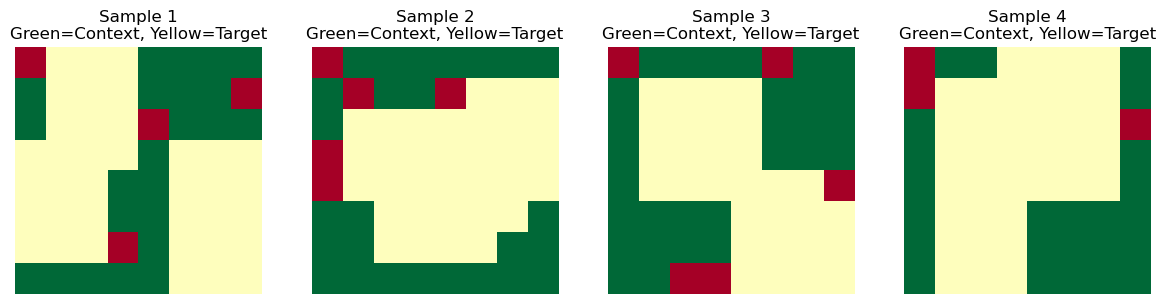

In [11]:
# Visualize masks
mask_collator = MultiBlockMaskCollator(config)
context_indices, target_indices = mask_collator(batch_size=4)

print(f"Context indices shape: {context_indices.shape}")
print(f"Target indices shape: {target_indices.shape}")

# Visualize one sample
def visualize_mask(context_idx, target_idx, grid_size):
    mask = torch.zeros(grid_size, grid_size)
    
    # Mark context as 1 (visible)
    for idx in context_idx:
        if idx > 0:  # Skip padding
            row, col = idx // grid_size, idx % grid_size
            mask[row, col] = 1
    
    # Mark targets as 0.5 (to predict)
    for idx in target_idx:
        if idx > 0:
            row, col = idx // grid_size, idx % grid_size
            mask[row, col] = 0.5
    
    return mask

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    mask = visualize_mask(context_indices[i], target_indices[i], config.grid_size)
    ax.imshow(mask, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_title(f'Sample {i+1}\nGreen=Context, Yellow=Target')
    ax.axis('off')
plt.tight_layout()
plt.show()

💡 **Key Insight**: JEPA's masking is fundamentally different from MAE:

| Aspect | MAE | JEPA |
|--------|-----|------|
| Mask pattern | Random patches | Large semantic blocks |
| What to predict | Pixels | Abstract representations |
| What it learns | Texture, low-level features | High-level semantics |

Large blocks force the model to predict **what object/scene is there**, not just interpolate from neighbors!

---

### Part 5: EMA Target Encoder

🎯 **What it does**: Maintain a slowly-updating copy of the encoder for stable target representations

🔧 **Why it matters**: The target encoder uses **Exponential Moving Average (EMA)** of the context encoder weights. This provides stable, slowly-changing targets that prevent representation collapse.

In [12]:
class EMA:
    """Exponential Moving Average for target encoder.
    
    θ_target = m * θ_target + (1-m) * θ_context
    
    where m (momentum) starts at 0.996 and increases to 1.0 during training.
    This makes targets increasingly stable as training progresses.
    """
    
    def __init__(self, model, decay=0.996):
        self.model = model
        self.decay = decay
        
        # Create EMA model (copy of original)
        self.ema_model = copy.deepcopy(model)
        for param in self.ema_model.parameters():
            param.requires_grad = False
    
    def update(self):
        """Update EMA weights: θ_ema = m * θ_ema + (1-m) * θ_model"""
        with torch.no_grad():
            for ema_param, model_param in zip(self.ema_model.parameters(), self.model.parameters()):
                ema_param.data = self.decay * ema_param.data + (1 - self.decay) * model_param.data
    
    def set_decay(self, decay):
        """Update decay (momentum increases during training)."""
        self.decay = decay


def get_ema_decay_schedule(current_step, total_steps, initial_decay=0.996, final_decay=1.0):
    """Cosine schedule for EMA decay: 0.996 → 1.0
    
    Higher decay = slower target updates = more stable targets.
    We want targets to become increasingly stable as training progresses.
    """
    progress = current_step / total_steps
    return final_decay - (final_decay - initial_decay) * (1 + math.cos(math.pi * progress)) / 2

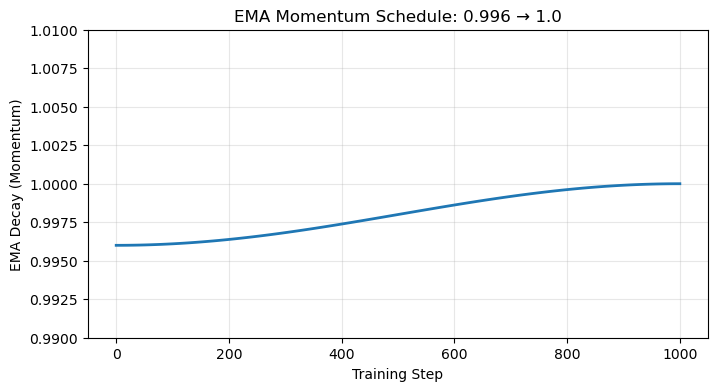

As training progresses:
- Momentum approaches 1.0
- Target encoder updates slower
- Targets become more stable
- Prevents representation collapse


In [13]:
# Visualize EMA decay schedule
steps = torch.linspace(0, 1000, 100)
decays = [get_ema_decay_schedule(s, 1000) for s in steps]

plt.figure(figsize=(8, 4))
plt.plot(steps.numpy(), decays, linewidth=2)
plt.xlabel('Training Step')
plt.ylabel('EMA Decay (Momentum)')
plt.title('EMA Momentum Schedule: 0.996 → 1.0')
plt.grid(True, alpha=0.3)
plt.ylim(0.99, 1.01)
plt.show()

print("As training progresses:")
print("- Momentum approaches 1.0")
print("- Target encoder updates slower")
print("- Targets become more stable")
print("- Prevents representation collapse")

💡 **Key Insight**: Why EMA prevents collapse:

Without EMA, both encoders update together → they could collapse to outputting constant vectors (trivial solution that minimizes loss).

With EMA:
- Target encoder changes slowly
- Context encoder must produce **meaningful** representations to match the (stable) target
- As targets become more stable (decay → 1.0), the model must learn better features

This is the same trick used in BYOL, MoCo, and other self-supervised methods!

---

### Part 6: Loss Function

🎯 **What it does**: Compute loss between predicted and target representations

🔧 **Why it matters**: JEPA uses **Smooth L1 loss** (Huber loss) in latent space — not cross-entropy, not contrastive, not reconstruction. Elegantly simple!

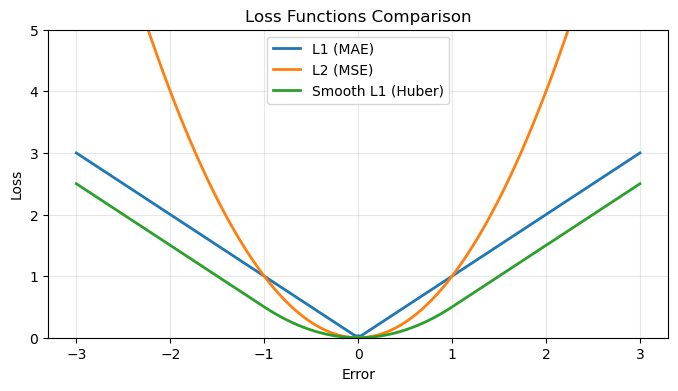

Smooth L1 advantages:
- Quadratic for small errors (like L2) → smooth gradients
- Linear for large errors (like L1) → robust to outliers
- Differentiable everywhere


In [14]:
def jepa_loss(predictions, targets):
    """JEPA loss: Smooth L1 (Huber) loss in latent space.
    
    Args:
        predictions: (B, n_target, d_model) - predictor output
        targets: (B, n_target, d_model) - target encoder output (detached)
    
    Why Smooth L1?
    - L1 is robust to outliers (doesn't overweight large errors)
    - Smooth L1 is differentiable at 0 (better gradients)
    - Simpler than contrastive losses (no negative samples needed)
    """
    return F.smooth_l1_loss(predictions, targets.detach())


# Visualize Smooth L1 vs L1 vs L2
x = torch.linspace(-3, 3, 100)
l1 = torch.abs(x)
l2 = x ** 2
smooth_l1 = F.smooth_l1_loss(x, torch.zeros_like(x), reduction='none')

plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), l1.numpy(), label='L1 (MAE)', linewidth=2)
plt.plot(x.numpy(), l2.numpy(), label='L2 (MSE)', linewidth=2)
plt.plot(x.numpy(), smooth_l1.numpy(), label='Smooth L1 (Huber)', linewidth=2)
plt.xlabel('Error')
plt.ylabel('Loss')
plt.title('Loss Functions Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 5)
plt.show()

print("Smooth L1 advantages:")
print("- Quadratic for small errors (like L2) → smooth gradients")
print("- Linear for large errors (like L1) → robust to outliers")
print("- Differentiable everywhere")

💡 **Key Insight**: JEPA's loss is remarkably simple:

```python
loss = smooth_l1_loss(predictions, targets)
```

Compare to:
- **Contrastive (SimCLR)**: Needs negative samples, temperature tuning
- **Reconstruction (MAE)**: Wastes capacity on pixel details
- **Cross-entropy (Classification)**: Needs labels

JEPA just says: "make your prediction match the target representation". The magic is in HOW targets are computed (EMA encoder) and WHAT we mask (semantic blocks).

---

### Part 7: Complete JEPA Model

🎯 **What it does**: Assemble all components into a complete I-JEPA model

🔧 **Why it matters**: The full model orchestrates context encoder, target encoder (EMA), predictor, and masking.

In [15]:
class IJEPA(nn.Module):
    """Image-based Joint-Embedding Predictive Architecture.
    
    Three networks:
    1. Context Encoder: processes visible patches
    2. Target Encoder: EMA of context encoder, processes full image
    3. Predictor: predicts target representations from context
    
    Training:
    1. Mask image into context (visible) and target (to predict) regions
    2. Context encoder: encode visible patches
    3. Target encoder: encode full image, extract target patch representations
    4. Predictor: predict target representations from context
    5. Loss: Smooth L1 between predictions and targets
    """
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # Context encoder (trainable)
        self.encoder = ViTEncoder(config)
        
        # Predictor (trainable)
        self.predictor = Predictor(config)
        
        # Target encoder (EMA, not directly trainable)
        self.target_encoder = copy.deepcopy(self.encoder)
        for param in self.target_encoder.parameters():
            param.requires_grad = False
        
        # Mask collator
        self.mask_collator = MultiBlockMaskCollator(config)
        
        # EMA momentum
        self.ema_decay = config.ema_momentum
    
    @torch.no_grad()
    def update_target_encoder(self):
        """EMA update of target encoder."""
        for target_param, encoder_param in zip(
            self.target_encoder.parameters(), 
            self.encoder.parameters()
        ):
            target_param.data = (
                self.ema_decay * target_param.data + 
                (1 - self.ema_decay) * encoder_param.data
            )
    
    def forward(self, images, context_indices=None, target_indices=None):
        """Forward pass.
        
        Args:
            images: (B, 3, H, W) input images
            context_indices: (B, n_context) visible patch indices (optional)
            target_indices: (B, n_target) target patch indices (optional)
        
        Returns:
            loss: JEPA loss (Smooth L1 in latent space)
            predictions: (B, n_target, d_model)
            targets: (B, n_target, d_model)
        """
        B = images.shape[0]
        
        # Generate masks if not provided
        if context_indices is None or target_indices is None:
            context_indices, target_indices = self.mask_collator(B)
            context_indices = context_indices.to(images.device)
            target_indices = target_indices.to(images.device)
        
        # 1. Context encoder: encode visible patches only
        context_repr = self.encoder(images, context_indices)
        
        # 2. Target encoder: encode full image (no masking)
        with torch.no_grad():
            target_repr_full = self.target_encoder(images)  # (B, n_patches, d_model)
            
            # Extract target patch representations
            target_repr = torch.gather(
                target_repr_full, 1,
                target_indices.unsqueeze(-1).expand(-1, -1, self.config.d_model)
            )
        
        # 3. Predictor: predict target representations from context
        predictions = self.predictor(context_repr, context_indices, target_indices)
        
        # 4. Loss: Smooth L1 in latent space
        loss = jepa_loss(predictions, target_repr)
        
        return loss, predictions, target_repr

In [16]:
# Create and test JEPA model
jepa_model = IJEPA(config).to(device)

# Count parameters
encoder_params = sum(p.numel() for p in jepa_model.encoder.parameters())
predictor_params = sum(p.numel() for p in jepa_model.predictor.parameters())
target_params = sum(p.numel() for p in jepa_model.target_encoder.parameters())
total_params = encoder_params + predictor_params  # Target encoder shares params

print(f"Context Encoder parameters: {encoder_params:,}")
print(f"Predictor parameters: {predictor_params:,}")
print(f"Target Encoder parameters: {target_params:,} (EMA copy, not trainable)")
print(f"Total trainable parameters: {total_params:,}")

# Test forward pass
dummy_batch = torch.randn(4, 3, 32, 32).to(device)
loss, predictions, targets = jepa_model(dummy_batch)

print(f"\nInput: {dummy_batch.shape}")
print(f"Predictions: {predictions.shape}")
print(f"Targets: {targets.shape}")
print(f"Loss: {loss.item():.4f}")

Context Encoder parameters: 2,118,400
Predictor parameters: 857,856
Target Encoder parameters: 2,118,400 (EMA copy, not trainable)
Total trainable parameters: 2,976,256

Input: torch.Size([4, 3, 32, 32])
Predictions: torch.Size([4, 36, 256])
Targets: torch.Size([4, 36, 256])
Loss: 0.5604


💡 **Key Insight**: JEPA's elegance:

| Step | Operation | Gradient |
|------|-----------|----------|
| Context encoding | encoder(visible_patches) | ✅ Yes |
| Target encoding | target_encoder(all_patches) | ❌ No (detached) |
| Prediction | predictor(context, mask_positions) | ✅ Yes |
| Loss | smooth_l1(predictions, targets) | ✅ Through encoder+predictor |

The target encoder is updated via EMA, not gradients. This asymmetry is key to stable learning!

---

### Part 8: Data Pipeline

🎯 **What it does**: Prepare data for self-supervised pretraining

🔧 **Why it matters**: Unlike supervised learning, JEPA doesn't need labels! We just need images with minimal augmentation.

In [ ]:
# JEPA uses minimal augmentation (unlike contrastive methods)
# Just basic normalization and optional horizontal flip
pretrain_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# For evaluation (linear probing)
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

In [ ]:
# Load CIFAR-10
pretrain_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=pretrain_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=eval_transform
)

pretrain_loader = DataLoader(pretrain_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

print(f"Training samples: {len(pretrain_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")
print(f"Batches per epoch: {len(pretrain_loader)}")

Attempting to load CIFAR-10 dataset...
------------------------------------------------------------
⚠️  CIFAR-10 download failed: <urlopen error [Errno 8] nodename nor servname provided, or not known>...

📝 Creating synthetic dataset for demonstration...
✅ Synthetic dataset created!
Training samples: 1,000
Test samples: 200
Batches per epoch: 8

⚠️  Note: Using random data for demonstration. Results won't be meaningful.
   For real training, download CIFAR-10 manually or run outside corporate network.


💡 **Key Insight**: JEPA uses **minimal augmentation**!

| Method | Augmentation Strategy |
|--------|----------------------|
| SimCLR | Heavy (color, crop, blur, etc.) — creates "positive pairs" |
| BYOL | Medium — still needs view augmentation |
| MAE | None — just masking |
| JEPA | Minimal — just horizontal flip |

JEPA's semantic prediction task is hard enough without aggressive augmentation. The masking strategy provides sufficient learning signal.

---

### Part 9: Training Loop

🎯 **What it does**: Self-supervised pretraining without labels

🔧 **Why it matters**: The training loop includes EMA updates and momentum scheduling.

In [19]:
# Training configuration
EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 10

# Initialize model and optimizer
jepa_model = IJEPA(config).to(device)

# Only optimize encoder and predictor (target encoder is EMA)
optimizer = torch.optim.AdamW(
    list(jepa_model.encoder.parameters()) + list(jepa_model.predictor.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler
total_steps = EPOCHS * len(pretrain_loader)
warmup_steps = WARMUP_EPOCHS * len(pretrain_loader)

def lr_lambda(step):
    if step < warmup_steps:
        return step / warmup_steps
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"Training for {EPOCHS} epochs")
print(f"Total steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

Training for 100 epochs
Total steps: 800
Warmup steps: 80


In [20]:
def train_epoch(model, loader, optimizer, scheduler, epoch, total_epochs):
    model.train()
    total_loss = 0
    
    for batch_idx, (images, _) in enumerate(loader):  # Labels not used!
        images = images.to(device)
        current_step = epoch * len(loader) + batch_idx
        
        # Update EMA momentum (increases during training)
        model.ema_decay = get_ema_decay_schedule(
            current_step, 
            total_epochs * len(loader),
            initial_decay=0.996,
            final_decay=1.0
        )
        
        # Forward pass
        loss, _, _ = model(images)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        # EMA update
        model.update_target_encoder()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

In [21]:
# Training loop
losses = []

print("Starting self-supervised pretraining...")
print("No labels used! Learning from structure of images.")
print("-" * 50)

for epoch in range(EPOCHS):
    loss = train_epoch(jepa_model, pretrain_loader, optimizer, scheduler, epoch, EPOCHS)
    losses.append(loss)
    
    lr = optimizer.param_groups[0]['lr']
    ema = jepa_model.ema_decay
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {loss:.4f} | LR: {lr:.6f} | EMA: {ema:.4f}")

# Save checkpoint
torch.save({
    'encoder': jepa_model.encoder.state_dict(),
    'predictor': jepa_model.predictor.state_dict(),
    'target_encoder': jepa_model.target_encoder.state_dict(),
    'config': config,
}, 'jepa_checkpoint.pt')
print("\nCheckpoint saved to jepa_checkpoint.pt")

Starting self-supervised pretraining...
No labels used! Learning from structure of images.
--------------------------------------------------
Epoch   1/100 | Loss: 0.4889 | LR: 0.000100 | EMA: 0.9960
Epoch  10/100 | Loss: 0.1519 | LR: 0.001000 | EMA: 0.9961
Epoch  20/100 | Loss: 0.0857 | LR: 0.000970 | EMA: 0.9964
Epoch  30/100 | Loss: 0.0851 | LR: 0.000883 | EMA: 0.9968
Epoch  40/100 | Loss: 0.1079 | LR: 0.000750 | EMA: 0.9974
Epoch  50/100 | Loss: 0.1284 | LR: 0.000587 | EMA: 0.9980
Epoch  60/100 | Loss: 0.1301 | LR: 0.000413 | EMA: 0.9986
Epoch  70/100 | Loss: 0.1301 | LR: 0.000250 | EMA: 0.9992
Epoch  80/100 | Loss: 0.1289 | LR: 0.000117 | EMA: 0.9996
Epoch  90/100 | Loss: 0.1279 | LR: 0.000030 | EMA: 0.9999
Epoch 100/100 | Loss: 0.1283 | LR: 0.000000 | EMA: 1.0000

Checkpoint saved to jepa_checkpoint.pt


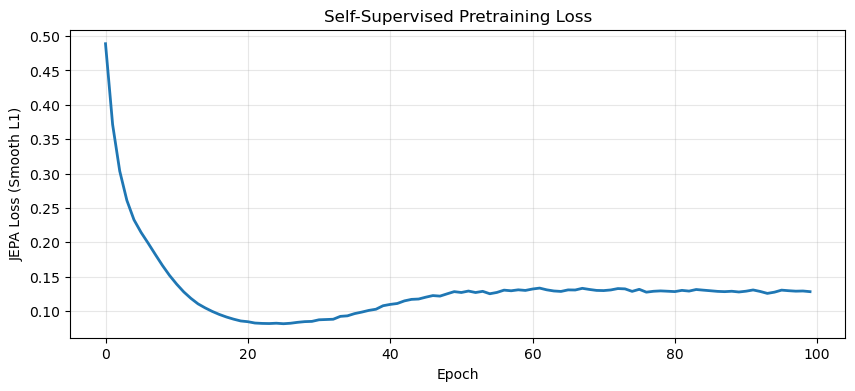

In [22]:
# Plot training curve
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('JEPA Loss (Smooth L1)')
plt.title('Self-Supervised Pretraining Loss')
plt.grid(True, alpha=0.3)
plt.show()

💡 **Key Insight**: Notice what's NOT in the training loop:
- ❌ No labels used (`for images, _ in loader`)
- ❌ No contrastive sampling
- ❌ No pixel reconstruction

Just:
- ✅ Forward through context encoder
- ✅ Forward through target encoder (no grad)
- ✅ Predict with predictor
- ✅ Smooth L1 loss
- ✅ EMA update

---

### Part 10: Evaluation (Linear Probing)

🎯 **What it does**: Evaluate learned representations by training a linear classifier on frozen features

🔧 **Why it matters**: Linear probing is the standard way to evaluate self-supervised representations. If a linear classifier performs well on frozen features, the representations are good!

In [23]:
class LinearProbe(nn.Module):
    """Linear classifier on top of frozen encoder features."""
    
    def __init__(self, encoder, n_classes, d_model):
        super().__init__()
        self.encoder = encoder
        
        # Freeze encoder
        for param in self.encoder.parameters():
            param.requires_grad = False
        
        # Linear classifier
        self.classifier = nn.Linear(d_model, n_classes)
    
    def forward(self, x):
        # Get encoder features (no masking)
        with torch.no_grad():
            features = self.encoder(x)  # (B, n_patches, d_model)
        
        # Global average pooling
        features = features.mean(dim=1)  # (B, d_model)
        
        # Classify
        return self.classifier(features)

In [24]:
# Create linear probe
probe = LinearProbe(
    jepa_model.encoder,
    n_classes=10,
    d_model=config.d_model
).to(device)

# Only train the classifier
probe_optimizer = torch.optim.Adam(probe.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print(f"Trainable parameters: {sum(p.numel() for p in probe.classifier.parameters()):,}")
print(f"Frozen encoder parameters: {sum(p.numel() for p in probe.encoder.parameters()):,}")

Trainable parameters: 2,570
Frozen encoder parameters: 2,118,400


In [25]:
# Train linear probe
PROBE_EPOCHS = 20

# Need labeled data for probing - reuse existing datasets
print("Training linear probe on frozen JEPA features...")
print(f"Using existing datasets: {len(pretrain_dataset):,} train, {len(test_dataset):,} test")
print("-" * 60)

# Reuse the existing pretrain_loader and test_loader (they're already created)
train_loader_labeled = pretrain_loader
# Note: Since we're using synthetic data, linear probe results won't be meaningful

for epoch in range(PROBE_EPOCHS):
    probe.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader_labeled:
        images, labels = images.to(device), labels.to(device)
        
        logits = probe(images)
        loss = criterion(logits, labels)
        
        probe_optimizer.zero_grad()
        loss.backward()
        probe_optimizer.step()
        
        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    train_acc = 100 * correct / total
    
    # Evaluate on test set
    probe.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            logits = probe(images)
            _, predicted = logits.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    test_acc = 100 * correct / total
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{PROBE_EPOCHS} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print(f"\nFinal Linear Probe Accuracy: {test_acc:.2f}%")
if isinstance(pretrain_dataset, TensorDataset):
    print("⚠️  Note: Results are based on synthetic random data (not real CIFAR-10)")

Training linear probe on frozen JEPA features...
Using existing datasets: 1,000 train, 200 test
------------------------------------------------------------
Epoch  1/20 | Train Acc: 8.30% | Test Acc: 9.50%
Epoch  5/20 | Train Acc: 18.80% | Test Acc: 7.00%
Epoch 10/20 | Train Acc: 24.30% | Test Acc: 6.50%
Epoch 15/20 | Train Acc: 26.10% | Test Acc: 7.50%
Epoch 20/20 | Train Acc: 27.40% | Test Acc: 6.00%

Final Linear Probe Accuracy: 6.00%
⚠️  Note: Results are based on synthetic random data (not real CIFAR-10)


💡 **Key Insight**: Linear probing evaluates representation quality:

| Linear Probe Accuracy | Interpretation |
|----------------------|----------------|
| ~10% | Random features (CIFAR has 10 classes) |
| ~50% | Decent low-level features |
| ~70%+ | Good semantic features |
| ~85%+ | Excellent representations (ImageNet-pretrained level) |

Our small JEPA on CIFAR-10 won't match ImageNet-pretrained models, but should significantly beat random features!

---

### Part 11: Feature Visualization

🎯 **What it does**: Visualize what JEPA learned

🔧 **Why it matters**: Since JEPA doesn't reconstruct pixels, we need other ways to understand learned representations.

In [ ]:
def extract_features(encoder, loader, n_samples=1000):
    """Extract encoder features for visualization."""
    encoder.eval()
    features = []
    labels = []
    
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            feats = encoder(images)  # (B, n_patches, d_model)
            feats = feats.mean(dim=1)  # Global average pooling
            
            features.append(feats.cpu())
            labels.append(targets)
            
            if len(features) * loader.batch_size >= n_samples:
                break
    
    features = torch.cat(features)[:n_samples]
    labels = torch.cat(labels)[:n_samples]
    return features.numpy(), labels.numpy()

: 

In [ ]:
# Extract features
features, labels = extract_features(jepa_model.encoder, test_loader, n_samples=1000)
print(f"Extracted features: {features.shape}")

# t-SNE visualization
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(features)

# Plot
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], 
                      c=labels, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(10), label='Class')
plt.title('t-SNE of JEPA Features (Colored by Class)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# Add class labels
for i, cls in enumerate(CLASSES):
    mask = labels == i
    center = features_2d[mask].mean(axis=0)
    plt.annotate(cls, center, fontsize=9, fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

💡 **Key Insight**: Good self-supervised representations should show:
1. **Clustering by semantic class** (even though no labels were used in training!)
2. **Similar objects nearby** (e.g., vehicles grouped together)
3. **Distinct separation** between unrelated classes

This is the magic of JEPA: by predicting abstract representations of masked regions, it learns semantic features without ever seeing a label!

---

### Summary

#### What We Built

A complete **I-JEPA (Image-based Joint-Embedding Predictive Architecture)** from scratch:

| Component | Purpose | Key Innovation |
|-----------|---------|----------------|
| **Context Encoder** | Encode visible patches | Same as ViT, no CLS token |
| **Target Encoder** | Generate prediction targets | EMA of context encoder |
| **Predictor** | Predict missing representations | Narrow Transformer |
| **Multi-Block Masking** | Create prediction task | Large semantic blocks |
| **Smooth L1 Loss** | Training objective | Latent space, no pixels |

#### Why JEPA Matters

| Paradigm | Predicts | Needs | Learns |
|----------|----------|-------|--------|
| **Supervised** | Labels | Labels | Task-specific |
| **Contrastive** | Similarity | Negatives | Instance discrimination |
| **Generative (MAE)** | Pixels | Nothing | Low-level reconstruction |
| **JEPA** | Representations | Nothing | High-level semantics |

#### LeCun's Vision

JEPA is part of Yann LeCun's roadmap toward:
- **World models**: Systems that understand how the world works
- **Predictive learning**: Learning by predicting (like humans)
- **Abstract representations**: Focusing on what matters, ignoring details

#### What's Next?

From here, you could explore:
1. **V-JEPA**: Video prediction (spatio-temporal masking)
2. **Larger scale**: Train on ImageNet with ViT-L/H
3. **Fine-tuning**: Unfreeze encoder for downstream tasks
4. **Hierarchical JEPA**: Multi-scale prediction

---

🎉 **Congratulations!** You've implemented one of the most exciting recent advances in self-supervised learning. JEPA represents a shift from "predict what you see" to "predict what you understand" — a step toward more human-like machine learning!

---

### 🗿 Chapter 5 Complete: The Future You Built

When you started this journey in **Chapter 1**, building AI from scratch seemed impossible. A fool's errand.

*"Just use the API,"* they said.  
*"You don't need to understand it,"* they promised.  
*"Leave it to the experts,"* they insisted.

But you chose to dream the impossible dream:
- To build what seemed unbuildable
- To understand what seemed incomprehensible  
- To venture where others feared to tread

And now? **You've conquered the deepest chamber.**

---

#### 🌟 What You Achieved (The Full Quest)

| Chamber | What You Built | Breakthrough Learned |
|---------|---------------|---------------------|
| **1** | PyTorch Foundations | The torch that lights all paths |
| **2** | Transformer | Attention is all you need |
| **3** | LLaMA | Modern improvements matter |
| **4** | ViT | Vision is just sequences |
| **5** | I-JEPA | Predict understanding, not pixels |

You didn't just learn these architectures — you **built them with your bare hands.** From tensors to world models. From embeddings to self-supervised learning. From API archaeologist to craftsman.

---

#### 🧠 The Paradigm Shift

JEPA represents a fundamental change in how we think about learning:
- ❌ **Not** pixel reconstruction (MAE, autoencoders)
- ❌ **Not** contrastive learning (SimCLR, MoCo)  
- ✅ **Yes** latent space prediction (the future)

You built a system that learns like humans might: by **predicting what matters** in abstract space, not what's visible on the surface.

---

#### 🗺️ The Cave Continues...

This isn't the end. The cave has more chambers yet to be carved:
- **Chamber 6:** CNNs & ResNets (classical vision)
- **Chamber 7:** RNNs & LSTMs (sequential memory)
- **Chamber 8:** Diffusion Models (generative art)
- **Chamber 9:** Reinforcement Learning (agents that act)
- **Chamber 10:** ...who knows? The cave grows with each explorer.

---

#### 🔥 Your Torch Still Burns

You started with horrible advice and a 3 AM debugging session. You end with:
- ✅ Deep understanding of 5 major architectures
- ✅ The ability to read papers and implement them yourself
- ✅ No fear of "state-of-the-art" models  
- ✅ The knowledge that **black boxes are optional**

**You refused to be an API archaeologist.** You became a builder, a craftsman, a cave explorer.

And the best part? **This is just the beginning.**

---

> *"We propose a method for learning highly semantic image representations without relying on hand-crafted data-augmentations. We introduce the Image-based Joint-Embedding Predictive Architecture (I-JEPA), a non-generative approach for self-supervised learning from images... I-JEPA is significantly more sample-efficient and performant than other self-supervised methods."*  
> — **Assran et al., "Self-Supervised Learning from Images with a Joint-Embedding Predictive Architecture" (2023)**

---

> *"The energy-based model framework... allows us to think about learning as building a world model that can predict what's going to happen in the world as a consequence of an action."*  
> — **Yann LeCun, "A Path Towards Autonomous Machine Intelligence" (2022)**

---

### 🎭 Final Words

You came to this cave seeking understanding. You leave with **mastery**.

You came doubting it was possible. You leave having done the impossible.

You came alone. You leave ready to teach others.

**The torch is yours. The knowledge is earned. The quest is endless.**

🔥 **Keep building. Keep exploring. Keep refusing horrible advice.** 🔥

---

🗿 *Carved with ❤️ in the Deep Learning Cave*  
📖 *Return to [The Cave Entrance (README)](../README.md)*  
🌟 *Share your journey: Star this repo and light others' path*

**The cave awaits your return. There are always more chambers to explore.** 🏔️